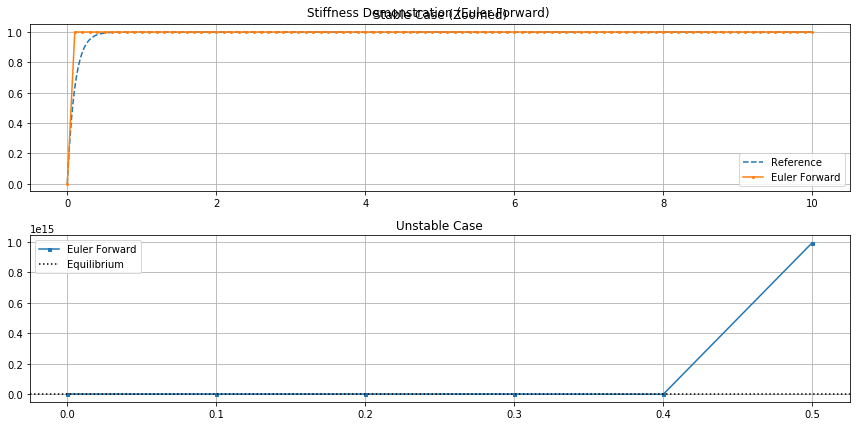

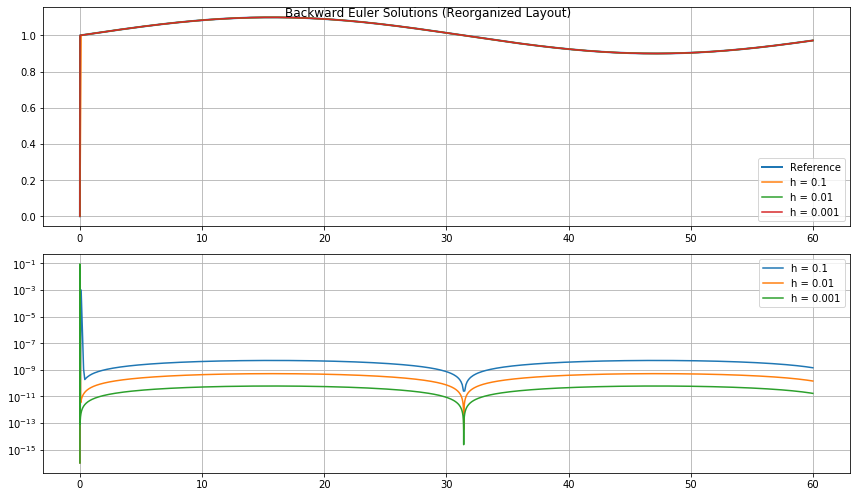

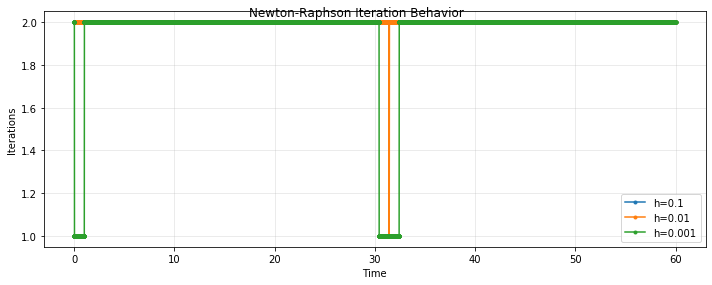

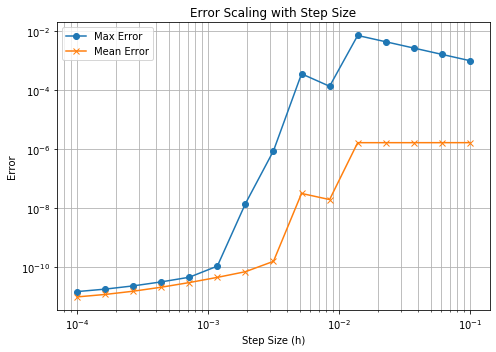

In [4]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

k_val   = 1e4
C_init  = 0.0
t_final = 60.0

def C_eq(t):
    return 1.0 + 0.1 * np.sin(0.1 * t)

def dCeq_dt(t):
    return 0.01 * np.cos(0.1 * t)

def f(t, C):
    return -k_val * (C - C_eq(t))

def analytical_solution(t_array):
    C_analytical = np.zeros_like(t_array)

    for i, t in enumerate(t_array):
        transient_term = C_init * np.exp(-k_val * t)
        qss_term = C_eq(t) - dCeq_dt(t) / k_val
        C_analytical[i] = transient_term + qss_term * (1 - np.exp(-k_val * t))

    return C_analytical

def euler_forward(h, T=t_final, C0=C_init):
    t = np.arange(0, T + h, h)
    C = np.zeros(len(t))
    C[0] = C0

    for n in range(len(t) - 1):
        C[n+1] = C[n] + h * f(t[n], C[n])

    return t, C

def newton_raphson(t_next, C_n, h, tol=1e-10, max_iter=20):

    dGdC = 1.0 + h * k_val
    C = C_n + h * f(t_next - h, C_n)
    iterations = 0

    for _ in range(max_iter):
        G = C - C_n - h * f(t_next, C)
        C_new = C - G / dGdC
        iterations += 1

        if abs(C_new - C) < tol:
            return C_new, iterations

        C = C_new

    return C, iterations

def euler_backward(h, T=t_final, C0=C_init):
    t = np.arange(0, T + h, h)
    C = np.zeros(len(t))
    C[0] = C0
    iters = []

    for n in range(len(t) - 1):
        C[n+1], it = newton_raphson(t[n+1], C[n], h)
        iters.append(it)

    return t, C, np.array(iters)

fig1 = plt.figure(figsize=(12, 6))
gs1 = fig1.add_gridspec(2, 1)

ax1 = fig1.add_subplot(gs1[0, 0])
ax2 = fig1.add_subplot(gs1[1, 0])

fig1.suptitle("Stiffness Demonstration (Euler Forward)")

h_stable = 1e-4
t_s, C_s = euler_forward(h_stable, T=0.01)

t_ref = np.linspace(0, 0.01, 5000)
C_ref = analytical_solution(t_ref)

ax1.plot(t_ref * 1e3, C_ref, linestyle='--', label="Reference")
ax1.plot(t_s * 1e3, C_s, marker='o', markersize=2, label="Euler Forward")
ax1.set_title("Stable Case (Zoomed)")
ax1.grid()
ax1.legend()

h_unstable = 0.1
t_u, C_u = euler_forward(h_unstable, T=0.5)

ax2.plot(t_u, C_u, marker='s', markersize=3, label="Euler Forward")
ax2.axhline(1.0, linestyle=':', color='black', label="Equilibrium")
ax2.set_title("Unstable Case")
ax2.grid()
ax2.legend()

plt.tight_layout()
plt.show()
plt.close()

step_sizes = [1e-1, 1e-2, 1e-3]
labels = ["0.1", "0.01", "0.001"]

t_fine = np.linspace(0, t_final, 10000)
C_exact = analytical_solution(t_fine)

fig2 = plt.figure(figsize=(12, 7))
gs2 = fig2.add_gridspec(2, 1)

ax21 = fig2.add_subplot(gs2[0, 0])
ax22 = fig2.add_subplot(gs2[1, 0])

fig2.suptitle("Backward Euler Solutions (Reorganized Layout)")

ax21.plot(t_fine, C_exact, linewidth=2, label="Reference")

results = {}
for h, lbl in zip(step_sizes, labels):
    t_b, C_b, iters_b = euler_backward(h)
    results[h] = (t_b, C_b, iters_b)
    ax21.plot(t_b, C_b, linestyle='-', label=f"h = {lbl}")

ax21.grid()
ax21.legend()

for h, lbl in zip(step_sizes, labels):
    t_b, C_b, _ = results[h]
    err = np.abs(C_b - analytical_solution(t_b))
    ax22.semilogy(t_b, err + 1e-16, label=f"h = {lbl}")

ax22.grid()
ax22.legend()

plt.tight_layout()
plt.show()
plt.close()

fig3, ax3 = plt.subplots(figsize=(10, 4))
fig3.suptitle("Newton-Raphson Iteration Behavior")

for h, lbl in zip(step_sizes, labels):
    t_b, _, iters_b = results[h]
    ax3.plot(t_b[1:], iters_b, linestyle='-', marker='.', label=f"h={lbl}")

ax3.set_xlabel("Time")
ax3.set_ylabel("Iterations")
ax3.grid(alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()
plt.close()

h_vals = np.logspace(-4, -1, 15)
max_err, mean_err = [], []

for h in h_vals:
    t_b, C_b, _ = euler_backward(h)
    err = np.abs(C_b - analytical_solution(t_b))

    mask = t_b > 0.01
    max_err.append(np.max(err[mask]) if np.any(mask) else np.nan)
    mean_err.append(np.mean(err[mask]) if np.any(mask) else np.nan)

fig4, ax4 = plt.subplots(figsize=(7, 5))

ax4.loglog(h_vals, max_err, marker='o', label="Max Error")
ax4.loglog(h_vals, mean_err, marker='x', label="Mean Error")

ax4.set_title("Error Scaling with Step Size")
ax4.set_xlabel("Step Size (h)")
ax4.set_ylabel("Error")
ax4.grid(True, which="both")
ax4.legend()

plt.tight_layout()
plt.show()
plt.close()